<a href="https://colab.research.google.com/github/Ali8089/Data_Science-and-ML/blob/ML_Algorithims/PCA_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [ ]:
X,y = load_breast_cancer(return_X_y=True)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [ ]:
class PCA_scratch:
  def __init__(self,dimensions):
    self.dimensions = dimensions # Number of principal components
    self.select_top = None       # Stores principal components
    self.eigenvalues = None      # Stores eigenvalues
    self.eigenvectors = None     # Stores eigenvectors

  def fit_transform(self,X_train):
    if self.dimensions == None:
      self.dimensions = X_train.shape[1]

    # Calculate covariance matrix
    covariance_matrix = np.cov(X_train,rowvar=False)

    # Get eigenvalues and eigenvectors
    self.eigenvalues,self.eigenvectors = np.linalg.eigh(covariance_matrix)

    # Sort by descending eigenvalues
    self.eigenvalues = self.eigenvalues[::-1]
    self.eigenvectors = self.eigenvectors[:,::-1]

    # Select top 'dimensions' eigenvectors
    self.select_top = self.eigenvectors[:,:self.dimensions]

    # Project data onto selected components
    return np.dot(X_train,self.select_top)

  def transform(self,X_test):
    # Project new data onto learned components
    return np.dot(X_test,self.select_top)

  def cum_sum_plot(self):
    # Calculate explained variance ratio
    ratio =  self.eigenvalues/(np.sum(self.eigenvalues))
    import matplotlib.pyplot as plt
    # Plot cumulative explained variance
    plt.plot(np.cumsum(ratio))

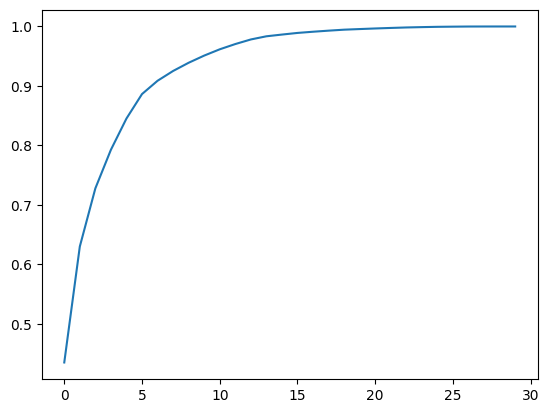

In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler() # Standardize features

X_train = ss.fit_transform(X_train) # Scale training data
X_test = ss.transform(X_test)       # Scale test data

pca = PCA_scratch(dimensions=5) # Initialize PCA with 5 components
X_train_trans = pca.fit_transform(X_train) # Fit PCA and transform training data
X_test_trans = pca.transform(X_test)       # Transform test data
pca.cum_sum_plot() # Plot cumulative variance

In [ ]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(X, x=X_train[:,0], y=X_train[:,1], z=X_train[:,2],
              color=y_train_trf) # Create 3D scatter plot
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20), # Adjust layout
    paper_bgcolor="LightSteelBlue",
)
fig.show() # Display plot

maximium accuracy before PCA: 0.9649122807017544


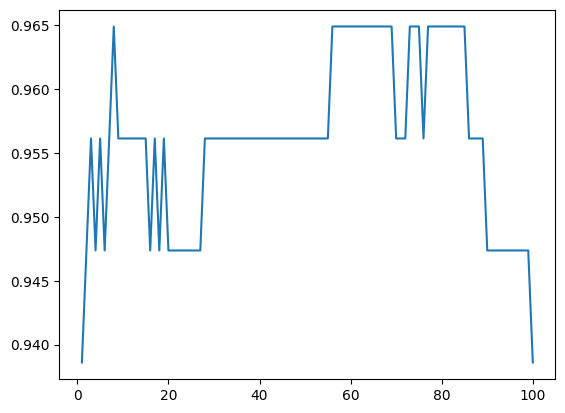

In [ ]:
accuracy_before = [None]*100 # List for accuracies before PCA
for n in range(0,101): # Loop for n_neighbors from 1 to 101
  from sklearn.neighbors import KNeighborsClassifier
  knn = KNeighborsClassifier(n_neighbors=n+1) # KNN classifier
  knn.fit(X_train,y_train) # Train on original data
  y_pred = knn.predict(X_test) # Predict on test data
  from sklearn.metrics import accuracy_score
  accuracy_before[n-1] = accuracy_score(y_test,y_pred) # Store accuracy

import matplotlib.pyplot as plt
plt.plot(range(1,101),accuracy_before) # Plot accuracy
print(f'maximium accuracy before PCA: {max(accuracy_before)}') # Print max accuracy

maximium accuracy after PCA: 0.9649122807017544


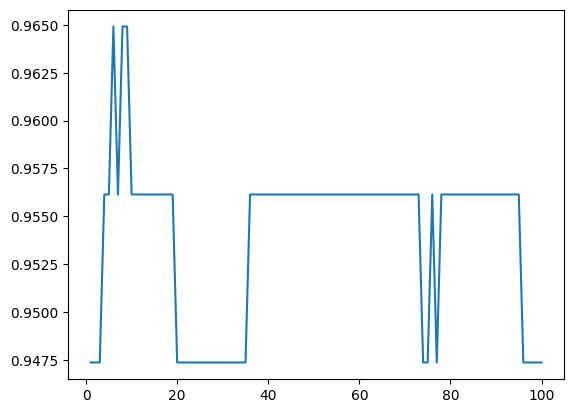

In [ ]:
accuracy_after = [None]*100 # List for accuracies after PCA
for n in range(0,101): # Loop for n_neighbors from 1 to 101
  from sklearn.neighbors import KNeighborsClassifier
  knn = KNeighborsClassifier(n_neighbors=n+1) # KNN classifier
  knn.fit(X_train_trans,y_train) # Train on PCA-transformed data
  y_pred = knn.predict(X_test_trans) # Predict on transformed test data
  from sklearn.metrics import accuracy_score
  accuracy_after[n-1] = accuracy_score(y_test,y_pred) # Store accuracy

import matplotlib.pyplot as plt
plt.plot(range(1,101),accuracy_after) # Plot accuracy
print(f'maximium accuracy after PCA: {max(accuracy_after)}') # Print max accuracy